<a href="https://colab.research.google.com/github/utsha95/Adaboost-n/blob/main/Adaboost_n.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [31]:
# Importing necessary libraries
import pandas as pd
import numpy as np
from sklearn.ensemble import AdaBoostClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, roc_curve, auc, accuracy_score, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
from sklearn.multiclass import OneVsRestClassifier
import seaborn as sns
import matplotlib.pyplot as plt

In [32]:
# Mount with google drive
from google.colab import drive
drive.mount("/content/drive", force_remount=True)

Mounted at /content/drive


In [33]:
# Load datasets
df = pd.read_csv('/content/drive/My Drive/Colab Notebooks/Student_Data (5).csv')

In [34]:
# Display the first few rows of the dataset to ensure it is loaded correctly
print(df.head())

             Timestamp                   Name  Gender                  DOB  \
0  2024-05-14 22:38:07         Sadia sultana   Female  2001-06-23 00:00:00   
1  2024-05-14 22:45:20       Fariha Tabassum   Female  2002-04-12 00:00:00   
2  2024-05-14 23:21:03    Maliha Adiv Nujhat   Female  2004-01-31 00:00:00   
3  2024-05-14 23:30:10  Farzana Akter Anamika  Female  2002-08-18 00:00:00   
4  2024-05-14 23:57:42            Fatema Alam  Female  2001-02-28 00:00:00   

  Academic performance (cgpa) except level-term:1-1  \
0                                  3.75-4.00 (high)   
1                                3.25-3.70 (medium)   
2                                3.25-3.70 (medium)   
3                                               NaN   
4                                3.25-3.70 (medium)   

  level-term:1-1 (can include ssc,hsc gpa)  Previous semester absence days  \
0                                       No                               3   
1                                      NaN  

In [35]:
# Check the exact column names in the DataFrame
print(df.columns)


Index(['Timestamp', 'Name', 'Gender', 'DOB',
       'Academic performance (cgpa) except level-term:1-1',
       'level-term:1-1 (can include ssc,hsc gpa)',
       ' Previous semester absence days', 'Academic achievement of mother',
       'Academic achievement of father ', 'Father's job', 'Mother's job',
       'Parents condition', 'No's of past class failures ', 'Travel duration',
       'Study session [Hour]', 'Health status [Physical]',
       'Health status [Spritual]', 'Health status [Emotional]',
       'Health status [Social]', 'Browsing time [Hour]',
       'Most used apps [Facebook]', 'Most used apps [Instagram]',
       'Most used apps [Tiktok]', 'Most used apps [Whatsapp]',
       'Most used apps [Messenger]', 'Most used apps [Telegram]',
       'Daily facebook browsing time [Hour]', 'Rest period [Hour]',
       'Physical activity', 'Extra Curricular involvement [Sports]',
       'Extra Curricular involvement [Arts]',
       'Extra Curricular involvement [Clubs]',
       'Ex

In [36]:
import pandas as pd

# Load datasets (re-added here to ensure df is defined if previous cells were
# not run)
df = pd.read_csv('/content/drive/My Drive/Colab Notebooks/Student_Data (5).csv')

# Assuming 'df' is your DataFrame
# Replacing the columns with exact names based on the output of df.columns
df_clean = df.drop(columns=['Timestamp', 'Name', 'DOB', 'level-term:1-1 (can include ssc,hsc gpa)',
                            'Father\'s job', 'Career focus/Passion'])  # Use correct column names here

# Drop rows with missing values
df_clean = df_clean.dropna()


In [37]:
import os

# Define the directory path
file_path = '/content/drive/My Drive/Colab Notebooks/'

# List contents of the directory
if os.path.exists(file_path):
    print(f"Contents of '{file_path}':")
    for item in os.listdir(file_path):
        print(item)
else:
    print(f"Directory '{file_path}' does not exist.")


Contents of '/content/drive/My Drive/Colab Notebooks/':
Fake News Data Pre-processing
Decision Tree
Student_Attribute.csv
Data Mining
Student_Response.csv
Neural Networks p.ipynb
Naive Bayes p.ipynb
KNN p.ipynb
Student_Data (5).csv
Student_Data (1).csv
Student_Data.csv
Randomforest n.ipynb
Randomforest t.ipynb
Deeplearning n.ipynb
Greedyhosting n.ipynb
Some ques.gdoc
Randomforest p.ipynb
Greedyhosting t.ipynb
Regression p 1.ipynb
Random Student .ipynb
Deeplearning p.ipynb
Anomaly detection p.ipynb
Decision tree p.ipynb
Deeplearning t.ipynb
Greedy hosting p.ipynb
K-means p.ipynb
Adaboost t.ipynb
Adaboost p.ipynb
Adaboost n.ipynb


In [38]:
# Encoding categorical variables
le = LabelEncoder()
for col in df_clean.select_dtypes(include=['object']).columns:
    df_clean[col] = le.fit_transform(df_clean[col])

In [39]:
# Defining the feature set and the target variable (Problem solving ability)
X = df_clean.drop(columns=['Problem solving'])
y = df_clean['Problem solving']

In [40]:
# Splitting the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [41]:
# Initializing the AdaBoost classifier
ada_clf = AdaBoostClassifier(n_estimators=100, random_state=42)
ada_clf.fit(X_train, y_train)

AdaBoostClassifier(n_estimators=100, random_state=42)

In [42]:
# Making predictions
y_pred = ada_clf.predict(X_test)
y_pred_proba = ada_clf.predict_proba(X_test)[:, 1]

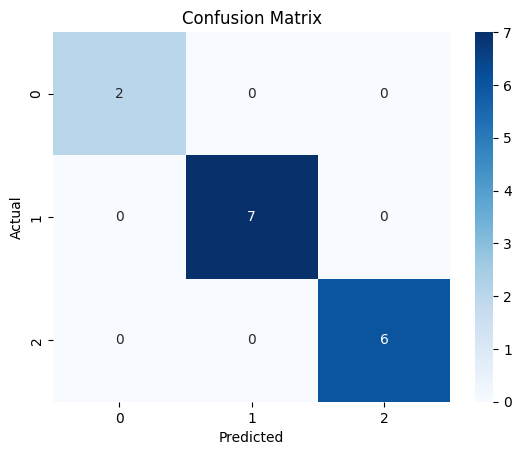

In [43]:
# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [44]:
# Standard Deviation of feature importances
std_dev = np.std(ada_clf.feature_importances_)
print(f"Standard Deviation of Feature Importances: {std_dev}")

Standard Deviation of Feature Importances: 0.07908114977768299


In [45]:
print(np.unique(y_test))


[0 1 2]


In [46]:
# For binary classification
# Extract the probability for the positive class (assuming binary classification)
y_pred_proba = ada_clf.predict_proba(X_test)[:, 1]

In [47]:
# Assuming y_test contains more than 2 classes
n_classes = len(np.unique(y_test))

In [48]:
# Binarize the output labels (One-vs-Rest strategy)
y_test_bin = label_binarize(y_test, classes=np.unique(y_test))

In [49]:
# Predict probabilities for each class
y_pred_proba = ada_clf.predict_proba(X_test)

In [50]:
# Compute ROC curve and ROC area for each class
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_pred_proba[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

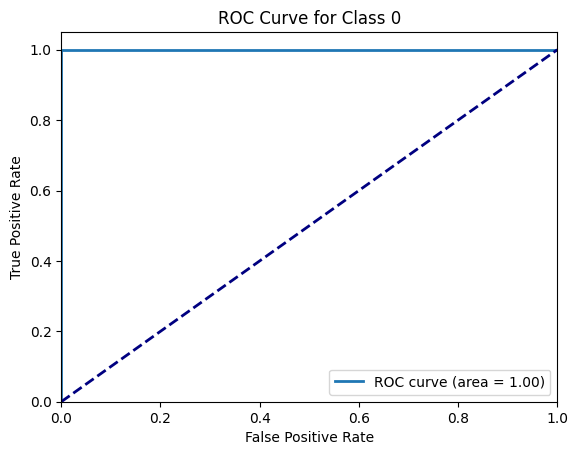

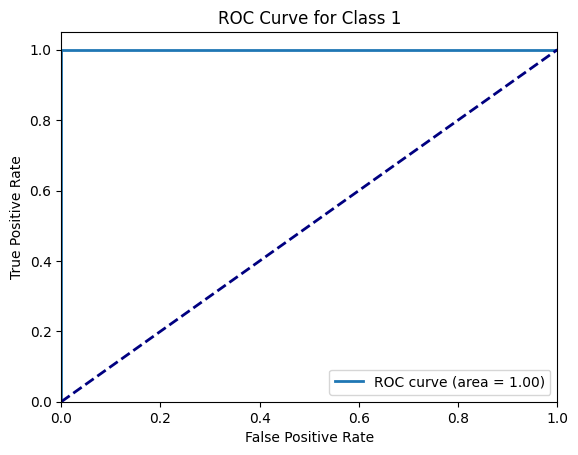

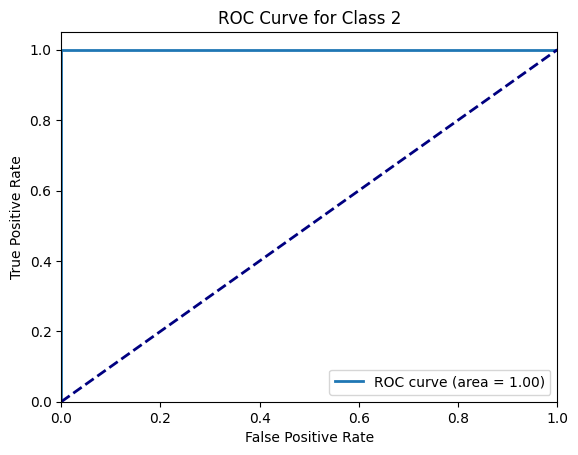

In [51]:
# Plot all ROC curves
for i in range(n_classes):
    plt.figure()
    plt.plot(fpr[i], tpr[i], lw=2, label=f'ROC curve (area = {roc_auc[i]:.2f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'ROC Curve for Class {i}')
    plt.legend(loc="lower right")
    plt.show()

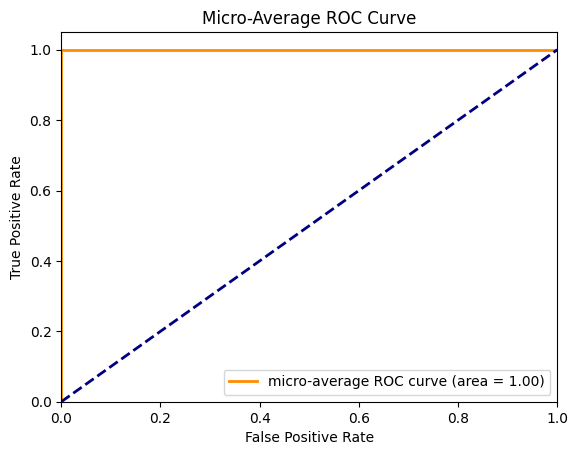

In [52]:
# Micro-average ROC curve and ROC area
fpr["micro"], tpr["micro"], _ = roc_curve(y_test_bin.ravel(), y_pred_proba.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

plt.figure()
plt.plot(fpr["micro"], tpr["micro"], color='darkorange', lw=2, label=f'micro-average ROC curve (area = {roc_auc["micro"]:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Micro-Average ROC Curve')
plt.legend(loc="lower right")
plt.show()


In [53]:
# Preprocessing
df.columns = df.columns.str.replace(r'\n', ' ').str.strip()  # Fix column names
drop_columns = ['Timestamp', 'Name', 'DOB', 'Father\'s job', 'Career focus/Passion']
df_clean = df.drop(columns=drop_columns)

In [54]:
# Encoding categorical features
label_encoders = {}
for column in df_clean.select_dtypes(include='object').columns:
    le = LabelEncoder()
    df_clean[column] = le.fit_transform(df_clean[column].astype(str))
    label_encoders[column] = le

In [55]:
# Accuracy and classification report
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy * 100:.2f}%")
print("Classification Report:")
print(classification_report(y_test, y_pred))


Accuracy: 100.00%
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         2
           1       1.00      1.00      1.00         7
           2       1.00      1.00      1.00         6

    accuracy                           1.00        15
   macro avg       1.00      1.00      1.00        15
weighted avg       1.00      1.00      1.00        15



In [56]:
# Calculate the correlation matrix of the cleaned dataset (df_clean)
correlation_matrix = df_clean.corr()

In [57]:
# Set up the matplotlib figure
plt.figure(figsize=(10, 8))

<Figure size 1000x800 with 0 Axes>

<Figure size 1000x800 with 0 Axes>

<Axes: >

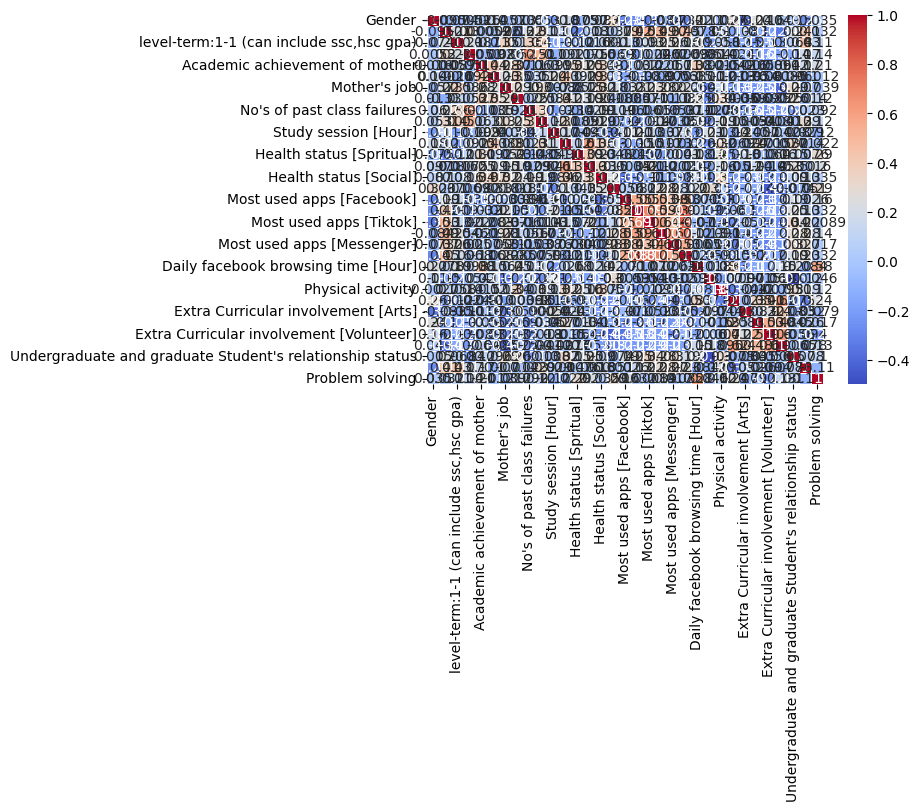

In [58]:
# Draw the heatmap
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", linewidths=0.5)

<Axes: >

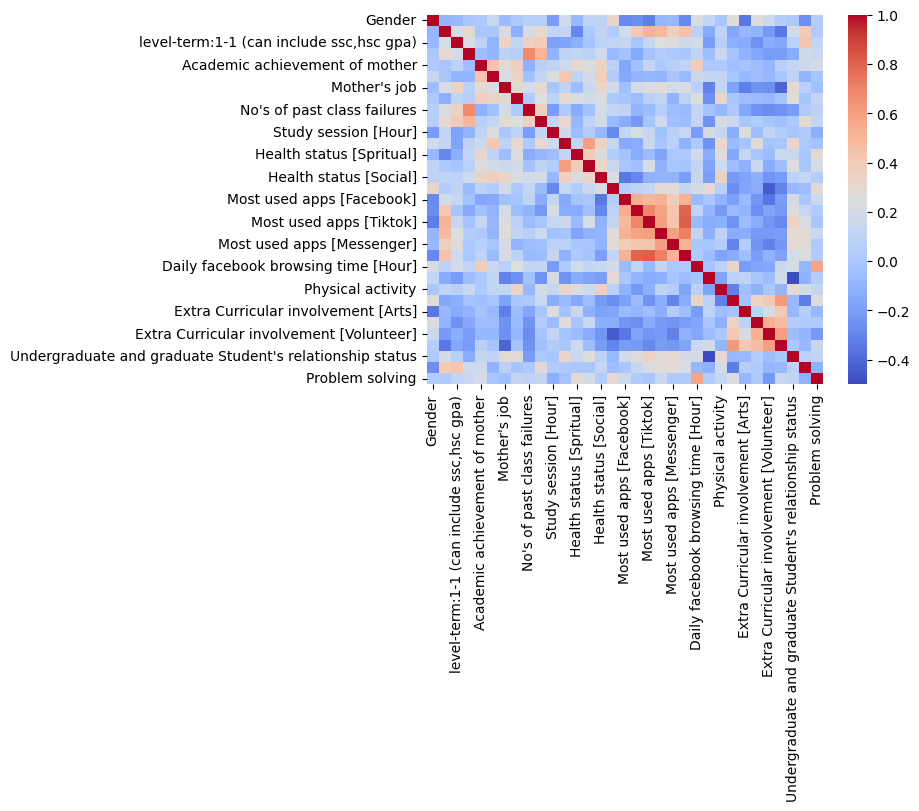

In [59]:
# Now we can draw the heatmap:
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', cbar=True)

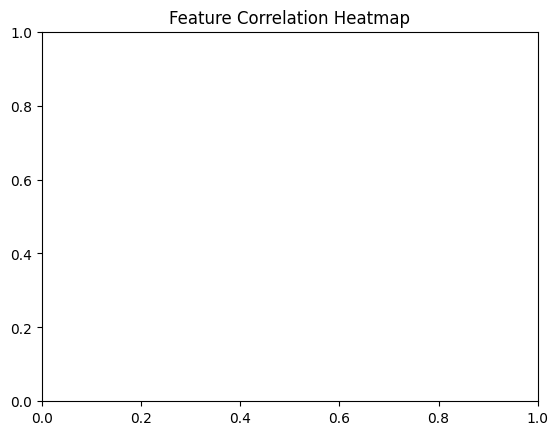

In [60]:
# Add title and display the heatmap
plt.title('Feature Correlation Heatmap')
plt.show()